# Scalping Strategy Rules

Develop and test scalping rules.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from strategy.scalping_logic import calculate_scalping_signals, detect_breakout, apply_stop_loss_take_profit

In [3]:
# Load data with indicators
ticker = 'AAPL'
from pathlib import Path
# Try multiple relative locations (notebook may live in subfolders)
candidates = [
    Path('../data/indicators') / f'{ticker}_features.csv',
    Path('../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data') / 'indicators' / f'{ticker}_features.csv',
]
for p in candidates:
    if p.exists():
        data = pd.read_csv(p, index_col=0, parse_dates=True)
        print(f'Loaded features from: {p}')
        break
else:
    raise FileNotFoundError(
        f'Could not find {ticker}_features.csv. Checked paths: {', '.join(str(x) for x in candidates)}'
    )

# Generate signals
data = calculate_scalping_signals(data)
data = detect_breakout(data)

data[['Close', 'scalp_signal', 'breakout_signal']].tail(20)

Loaded features from: ..\..\..\..\data\indicators\AAPL_features.csv
2025-12-14 20:02:11 - strategy.scalping_logic - INFO - Generated scalping signals for 1436 rows
2025-12-14 20:02:11 - strategy.scalping_logic - INFO - Detected 181 breakouts


c:\Users\Nihar\Documents\GitHub\oop\SnowMore\algo-trading-project\notebooks\../src\strategy\scalping_logic.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.   0.   0.   0.   0.   0.  -1.5 -1.5 -1.5  0.   0.   0.   0.   0.
  0.   0.   0.   0.   1.5  0.  -1.5 -1.5  0.   0.   0.  -1.5 -1.5 -1.5
 -1.5  0.   0.  -1.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 -1.5  0.  -1.5 -1.5  0.   0.   1.5  1.5  0.  -1.5 -1.5  0.   1.5  0.
  0.   0.   0.   0.   0.   0.   0.   1.5  0.   0.   0.   0.  -1.5  0.
 -1.5  0.   0.   0.   0.   1.5  0.   0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['vol_spike'], 'scalp_signal'] *= 1.5


,Close,scalp_signal,breakout_signal
2025-11-14 00:00:00,245.380203,-1.0,0
2025-11-17 00:00:00,245.380203,-1.0,0
2025-11-18 00:00:00,245.380203,-1.0,0
2025-11-19 00:00:00,245.380203,-1.0,0
2025-11-20 00:00:00,245.380203,-1.0,0
2025-11-21 00:00:00,245.380203,-1.0,0
2025-11-24 00:00:00,245.380203,-1.0,0
2025-11-25 00:00:00,245.380203,-1.0,0
2025-11-26 00:00:00,245.380203,-1.0,0
2025-11-28 00:00:00,245.380203,-1.0,0


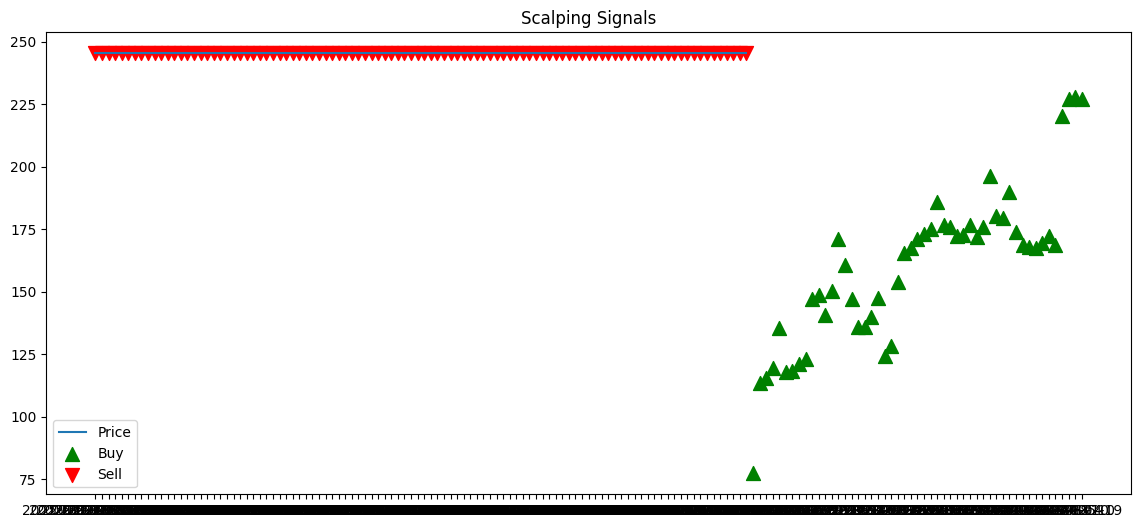

In [4]:
# Visualize signals
plt.figure(figsize=(14, 6))
plt.plot(data.index[-100:], data['Close'].iloc[-100:], label='Price')

buy_signals = data[data['scalp_signal'] > 0].iloc[-100:]
sell_signals = data[data['scalp_signal'] < 0].iloc[-100:]

plt.scatter(buy_signals.index, buy_signals['Close'], color='g', marker='^', s=100, label='Buy')
plt.scatter(sell_signals.index, sell_signals['Close'], color='r', marker='v', s=100, label='Sell')

plt.title('Scalping Signals')
plt.legend()
plt.show()